## GARCH Volatility Forecasting Model

In this notebook, we build and evaluate a GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model to forecast the future realized volatility of 2800.HK.  

Imports

In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load Processed Volatility & Return Data

We import the pre-exported datasets created in the data-processing notebook

In [3]:
# Load future-realized volatility target for 2800.HK
df = pd.read_excel('../data/hsi_vol.xlsx').set_index('date')
hsi = df['2800.HK'] # select target column explicitly

# Load log returns for naive baseline volatility computation
log_ret = pd.read_excel('../data/hsi_log_ret.xlsx').set_index('date')

hsi, log_ret # Quick display for sanity check

(date
 2002-05-14   -3.178702
 2002-05-15   -3.173177
 2002-05-16   -3.122987
 2002-05-17   -3.165196
 2002-05-21   -3.309047
                 ...   
 2025-11-04   -2.941056
 2025-11-05   -2.930590
 2025-11-06   -3.011233
 2025-11-07   -3.003996
 2025-11-10   -3.021088
 Name: 2800.HK, Length: 5797, dtype: float64,
              2800.HK
 date                
 2002-05-14 -0.004246
 2002-05-15  0.012685
 2002-05-16  0.000000
 2002-05-17  0.012526
 2002-05-21 -0.025211
 ...              ...
 2025-12-03 -0.011499
 2025-12-04  0.007681
 2025-12-05  0.005341
 2025-12-08 -0.011481
 2025-12-09 -0.014735
 
 [5818 rows x 1 columns])

### Fit GARCH(1,1) and Generate Out-of-Sample Volatility Forecasts

We estimate a GARCH(1,1) model on the training period of daily log returns. 

In [4]:
# Define out-of-sample cutoff date
split_date = '2021-12-31'

# Scale returns to percentages (ARCH/GARCH models typically assume % returns)
model = arch_model(log_ret * 100, vol='GARCH', p=1, q=1, o=1)

# Fit GARCH model using only data before the split_date (prevents look-ahead bias)
res = model.fit(disp='off', last_obs=split_date)

# Forecast future variance over the next 21 trading days (≈ 1 month)
# Monte-Carlo forecasting (1000 simulated paths)
forecasts = res.forecast(
    horizon=21, 
    start=split_date,
    method='simulation', 
    simulations=1000
).variance

# Aggregate 21-day variance to match realized volatility target’s definition
sigma2_21_forecast = forecasts.sum(axis=1)

# Convert variance forecast into log-realized volatility units for evaluation
y_pred = 0.5 * np.log(sigma2_21_forecast / (100 * 100))

res, y_pred # Display fitted model summary and volatility forecasts


(                   Constant Mean - GJR-GARCH Model Results                    
 Dep. Variable:                2800.HK   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                  GJR-GARCH   Log-Likelihood:               -7887.21
 Distribution:                  Normal   AIC:                           15784.4
 Method:            Maximum Likelihood   BIC:                           15816.9
                                         No. Observations:                 4846
 Date:                Tue, Dec 09 2025   Df Residuals:                     4845
 Time:                        18:03:09   Df Model:                            1
                                   Mean Model                                 
                  coef    std err          t      P>|t|       95.0% Conf. Int.
 -----------------------------------------------------------------------------
 mu             0.0181  1.641e-02      1.10

### Align True vs. Predicted Volatility Series

In [5]:
# Extract true realized volatility strictly from the OOS period
y_true = hsi['2021-12-31':]

# Align predictions and true values on matching dates only
valid_idx = y_true.index.intersection(y_pred.index)

y_true = y_true.loc[valid_idx]
y_pred = y_pred.loc[valid_idx]

### Forecast Performance Evaluation

We assess how well the GARCH model predicts future realized volatility

In [6]:
# Performance evaluation of baseline model
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'MSE: {mse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}')

MSE: 0.124, MAE: 0.253, R²: -0.219


### Convert Volatility Back to Annualized Percentage Units

The naive and true volatility series are currently expressed as log-realized variance.
To make the evaluation interpretable, we convert them to annualized volatility percentages.

In [7]:
ann_true = np.exp(y_true) * np.sqrt(12) *100
ann_pred = np.exp(y_pred) * np.sqrt(12) *100

### Visualizing GARCH vs. True Annualized Volatility

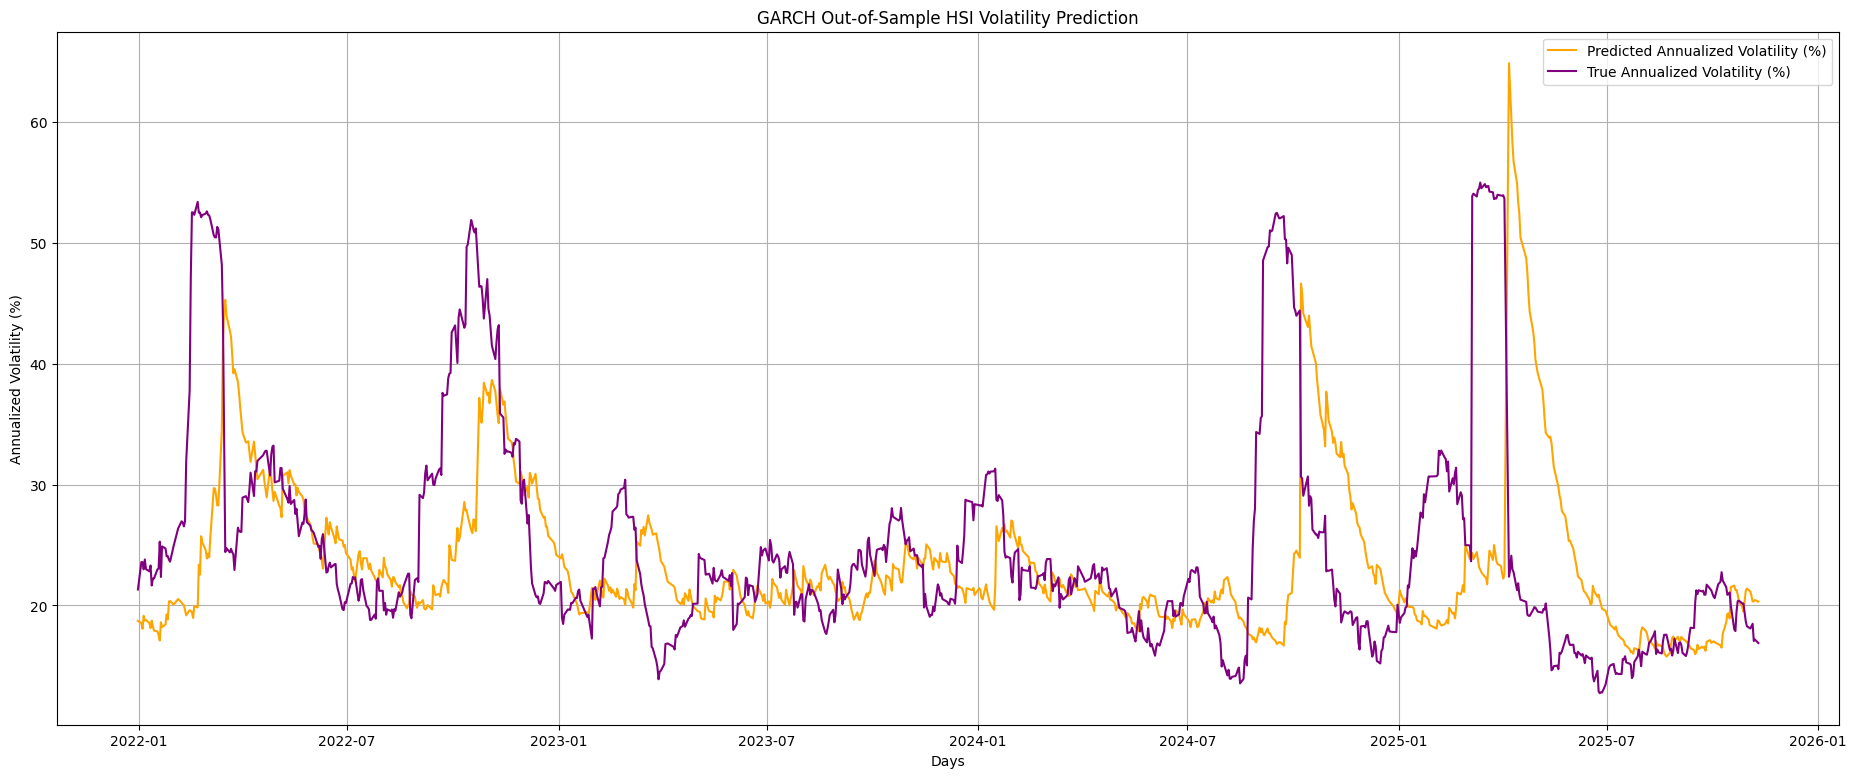

In [8]:
plt.figure(figsize=(23,9))
plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange') # CUHK Colors
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple') # CUHK Colors
plt.title('GARCH Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

### Export GARCH OOS Forecasts

In [9]:
# y_pred.to_excel('../results/garch_oos_pred.xlsx')